#  Clasificación MLP 


**Objetivo:** Entrenar y evaluar un modelo MLP, compararlo con EfficientNetB0 y analizar críticamente los resultados.

**Clases:** 10 categorías de condiciones foliares en caña de azúcar
- Hoja Amarilla, Mancha Parda, Mancha de Anillo, Mosaico, Muermo Rojo, Tizon Bacteriano, Roya, Carbon, 
- Además de ejemplos de hojas Sanas y Secas

## 1. IMPORTAR LIBRERÍAS

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_efficientnet
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.4.3


## 2. CONFIGURACIÓN Y CARGA DE DATOS

In [18]:
# Parámetros globales
IMG_SIZE = 128
IMG_SIZE_MLP = 128  # Tamaño original mantenido
BATCH_SIZE = 32
NUM_CLASSES = 10
SEED = 42

# Rutas de datos
base_dir = "../data"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Obtener nombres de clases
class_names = sorted(os.listdir(train_dir))
print(f"Clases ({len(class_names)}): {class_names}")

Clases (10): ['carbon', 'hoja_amarilla', 'mancha_anillo', 'mancha_parda', 'mosaico', 'muermo_rojo', 'roya', 'sanas', 'secas', 'tizon_bacteriano']


## 4. PREPROCESAMIENTO DE IMÁGENES PARA MLP

In [19]:
# Carga eficiente usando tf.keras.utils.image_dataset_from_directory para evitar CRASH por RAM
print(f"\nConfigurando Dataset desde el disco para MLP (0% riesgo de Crash)...\n")

train_ds_mlp = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE_MLP, IMG_SIZE_MLP),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    seed=SEED
)
val_ds_mlp = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE_MLP, IMG_SIZE_MLP),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    seed=SEED
)
test_ds_mlp = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE_MLP, IMG_SIZE_MLP),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    seed=SEED,
    shuffle=False
)

# Normalizar (Dividir entre 255) al vuelo mapeando el dataset
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds_mlp = train_ds_mlp.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_ds_mlp = val_ds_mlp.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
test_ds_mlp = test_ds_mlp.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

print("\nDatasets configurados exitosamente. RAM optimizada.")



Configurando Dataset desde el disco para MLP (0% riesgo de Crash)...

Found 5946 files belonging to 10 classes.
Found 1273 files belonging to 10 classes.
Found 1273 files belonging to 10 classes.

Datasets configurados exitosamente. RAM optimizada.


## 5. MODELO MLP - ENTRENAMIENTO

In [20]:
from tensorflow.keras.regularizers import l2

# Construcción del MLP OPTIMIZADO: Reduciendo tasas de Dropout para minimizar el 'ruido'
# en las métricas de validación y ajustando la tasa de aprendizaje para mayor estabilidad,
# sin modificar el tamaño de las imágenes.
reg = l2(1e-4)

mlp_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE_MLP, IMG_SIZE_MLP, 3)),
    layers.Flatten(),
    layers.Dense(512, activation='relu', kernel_regularizer=reg, name='dense_0_super'),
    layers.BatchNormalization(),
    layers.Dropout(0.2), # Reducido para menor ruido y fluctuación
    layers.Dense(512, activation='relu', kernel_regularizer=reg, name='dense_1_super'),
    layers.BatchNormalization(),
    layers.Dropout(0.2), 
    layers.Dense(256, activation='relu', kernel_regularizer=reg, name='dense_2_super'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu', kernel_regularizer=reg, name='dense_3_super'),
    layers.BatchNormalization(),
    layers.Dropout(0.1), # Reducido
    layers.Dense(128, activation='relu', kernel_regularizer=reg, name='dense_4_super'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(64, activation='relu', kernel_regularizer=reg, name='dense_5_super'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(64, activation='relu', kernel_regularizer=reg, name='dense_6_super'),
    layers.BatchNormalization(),
    layers.Dropout(0.1), # Reducido
    layers.Dense(32, activation='relu', kernel_regularizer=reg, name='dense_7_super'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(NUM_CLASSES, activation='softmax', name='output_super')
])

# Optimizador con learning rate más bajo para evitar saltos (ruido) en la pérdida
mlp_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, weight_decay=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


In [21]:
# ========================================
# VERIFICACIÓN DE RECURSOS (ANTES DEL ENTRENAMIENTO)
# ========================================
import psutil
import gc

print("\nVERIFICACION DE RECURSOS DEL SISTEMA")
print("="*70)
gc.collect()
tf.keras.backend.clear_session()

memory = psutil.virtual_memory()

print(f"\nINFORMACION DEL MODELO MLP:")
print(f"  Parámetros totales: {mlp_model.count_params():,}")
print(f"  RAM disponible: {memory.available / 1e9:.2f}GB")
print("  -> Al usar tf.data.Dataset (sin np.vstack), los datos se cargarán por lotes.")
print("     ¡Esto previene los crasheos de memoria RAM al 100%!\n")
print("Sistema listo para entrenar.\n")



VERIFICACION DE RECURSOS DEL SISTEMA

INFORMACION DEL MODELO MLP:
  Parámetros totales: 25,631,338
  RAM disponible: 3.24GB
  -> Al usar tf.data.Dataset (sin np.vstack), los datos se cargarán por lotes.
     ¡Esto previene los crasheos de memoria RAM al 100%!

Sistema listo para entrenar.



In [22]:
print(" Iniciando entrenamiento (máx 45 épocas con early stopping)...\n")

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
model_checkpoint = ModelCheckpoint('../models/mlp_best_model.keras', monitor='val_loss', save_best_only=True)

mlp_history = mlp_model.fit(
    train_ds_mlp,
    validation_data=val_ds_mlp,
    epochs=45,
    callbacks=[early_stop, reduce_lr, model_checkpoint],
    verbose=1
)

# Save model manually
mlp_model.save('../models/mlp_best_model.keras')
print('Modelo guardado como mlp_best_model.keras en ../models')


 Iniciando entrenamiento (máx 45 épocas con early stopping)...

Epoch 1/45
186/186 ━━━━━━━━━━━━━━━━━━━━ 129s 650ms/step - accuracy: 0.1401 - loss: 2.9761 - val_accuracy: 0.1445 - val_loss: 2.9884 - learning_rate: 1.0000e-04
Epoch 2/45
186/186 ━━━━━━━━━━━━━━━━━━━━ 125s 661ms/step - accuracy: 0.2107 - loss: 2.5693 - val_accuracy: 0.2852 - val_loss: 2.3309 - learning_rate: 1.0000e-04
Epoch 3/45
186/186 ━━━━━━━━━━━━━━━━━━━━ 122s 656ms/step - accuracy: 0.2598 - loss: 2.3548 - val_accuracy: 0.3362 - val_loss: 2.1331 - learning_rate: 1.0000e-04
Epoch 4/45
186/186 ━━━━━━━━━━━━━━━━━━━━ 122s 655ms/step - accuracy: 0.3241 - loss: 2.2119 - val_accuracy: 0.3881 - val_loss: 1.9826 - learning_rate: 1.0000e-04
Epoch 5/45
186/186 ━━━━━━━━━━━━━━━━━━━━ 121s 649ms/step - accuracy: 0.3490 - loss: 2.1134 - val_accuracy: 0.3315 - val_loss: 2.1287 - learning_rate: 1.0000e-04
Epoch 6/45
186/186 ━━━━━━━━━━━━━━━━━━━━ 122s 657ms/step - accuracy: 0.3796 - loss: 2.0086 - val_accuracy: 0.4603 - val_loss: 1.7825 - le

Generando grafica de entrenamiento...


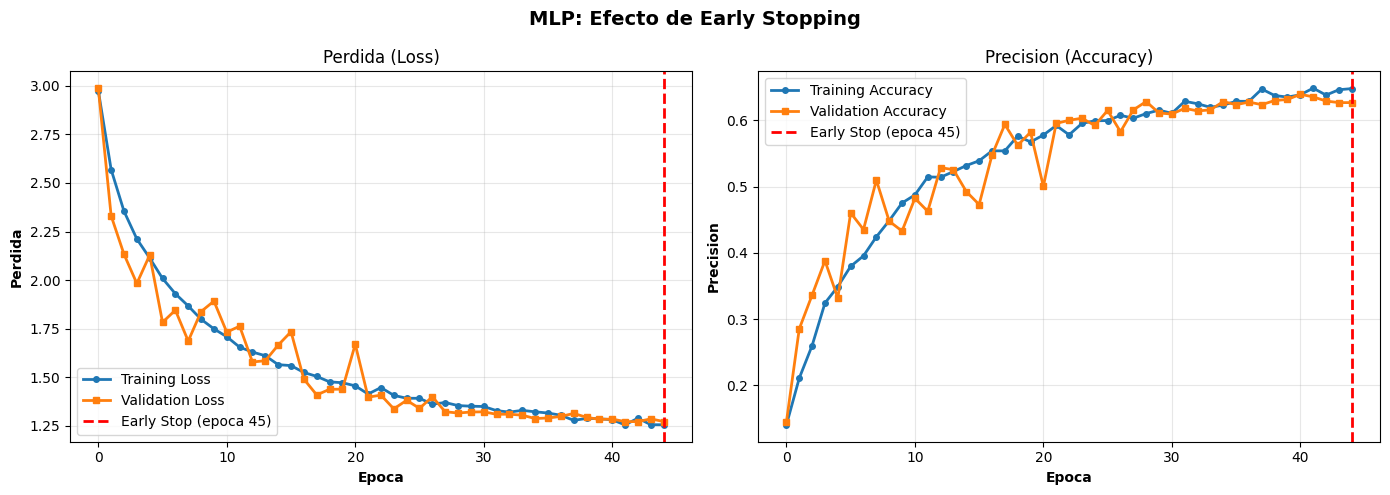

Grafica guardada: outputs/graphics/01_mlp_early_stopping_effect.png

ANALISIS DE REGULARIZACION

Epocas entrenadas: 45 de 45
  Perdida Entrenamiento: 1.2548
  Perdida Validacion: 1.2714
  Diferencia: 0.0166

  Precision Entrenamiento: 0.6480
  Precision Validacion: 0.6269

EXCELENTE: El modelo generaliza bien (diferencia < 0.1)


In [23]:
# Visualización del efecto de Early Stopping
print("Generando grafica de entrenamiento...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP: Efecto de Early Stopping', fontsize=14, fontweight='bold')

axes[0].plot(mlp_history.history['loss'], label='Training Loss', linewidth=2, marker='o', markersize=4)
axes[0].plot(mlp_history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s', markersize=4)
stop_epoch = len(mlp_history.history['loss'])
axes[0].axvline(x=stop_epoch-1, color='red', linestyle='--', linewidth=2, label=f'Early Stop (epoca {stop_epoch})')
axes[0].set_xlabel('Epoca', fontweight='bold')
axes[0].set_ylabel('Perdida', fontweight='bold')
axes[0].set_title('Perdida (Loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(mlp_history.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o', markersize=4)
axes[1].plot(mlp_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s', markersize=4)
axes[1].axvline(x=stop_epoch-1, color='red', linestyle='--', linewidth=2, label=f'Early Stop (epoca {stop_epoch})')
axes[1].set_xlabel('Epoca', fontweight='bold')
axes[1].set_ylabel('Precision', fontweight='bold')
axes[1].set_title('Precision (Accuracy)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/graphics/01_mlp_early_stopping_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada: outputs/graphics/01_mlp_early_stopping_effect.png")

epochs_trained = len(mlp_history.history['loss'])
final_train_loss = mlp_history.history['loss'][-1]
final_val_loss = mlp_history.history['val_loss'][-1]
final_train_acc = mlp_history.history['accuracy'][-1]
final_val_acc = mlp_history.history['val_accuracy'][-1]

print("\n" + "="*70)
print("ANALISIS DE REGULARIZACION")
print("="*70)
print(f"\nEpocas entrenadas: {epochs_trained} de 45")
print(f"  Perdida Entrenamiento: {final_train_loss:.4f}")
print(f"  Perdida Validacion: {final_val_loss:.4f}")
print(f"  Diferencia: {abs(final_train_loss - final_val_loss):.4f}")
print(f"\n  Precision Entrenamiento: {final_train_acc:.4f}")
print(f"  Precision Validacion: {final_val_acc:.4f}")

if abs(final_train_loss - final_val_loss) < 0.1:
    print(f"\nEXCELENTE: El modelo generaliza bien (diferencia < 0.1)")
elif abs(final_train_loss - final_val_loss) < 0.2:
    print(f"\nBUENO: Generalizacion aceptable (diferencia < 0.2)")
else:
    print(f"\nADVERTENCIA: OVERFITTING detectado")


## 6. EVALUACIÓN MLP

No se encontró mlp_best_model.keras . Usando modelo en memoria (entrenado recientemente).
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step

RESULTADOS MLP:
  Accuracy:  0.6544
  Precision: 0.6637
  Recall:    0.6544
  F1-Score:  0.6548

Reporte por clase (MLP):
                  precision    recall  f1-score   support

          carbon       0.91      0.96      0.94        75
   hoja_amarilla       0.70      0.62      0.66       150
   mancha_anillo       0.76      0.68      0.72       105
    mancha_parda       0.75      0.76      0.76       150
         mosaico       0.61      0.62      0.61       150
     muermo_rojo       0.45      0.67      0.53       150
            roya       0.50      0.40      0.45       150
           sanas       0.71      0.68      0.70       150
           secas       0.59      0.44      0.51        43
tizon_bacteriano       0.75      0.73      0.74       150

        accuracy                           0.65      1273
       macro avg       0.67      0.66      0.66  

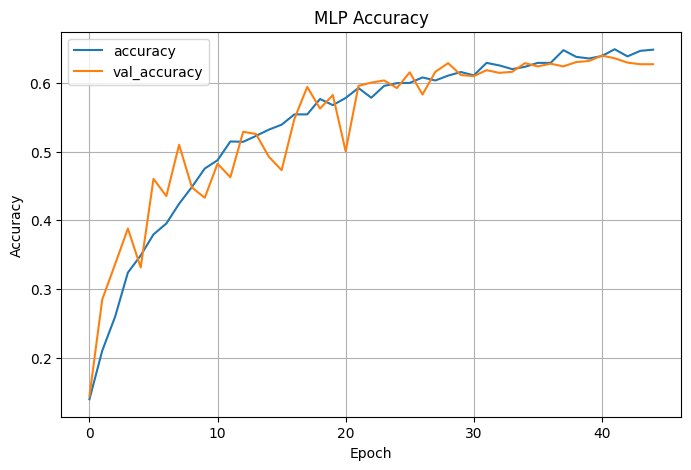

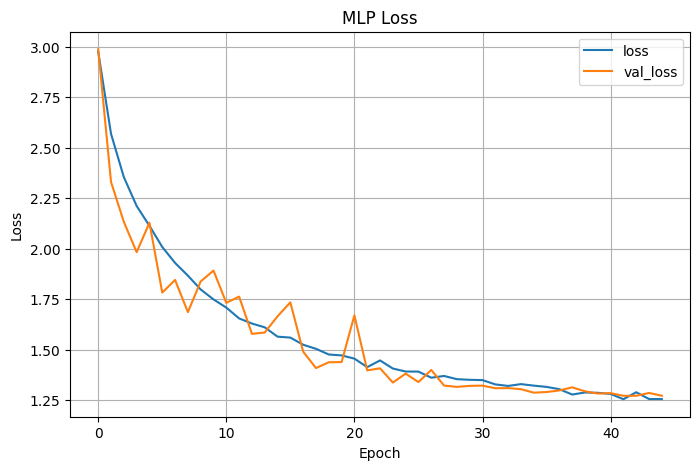

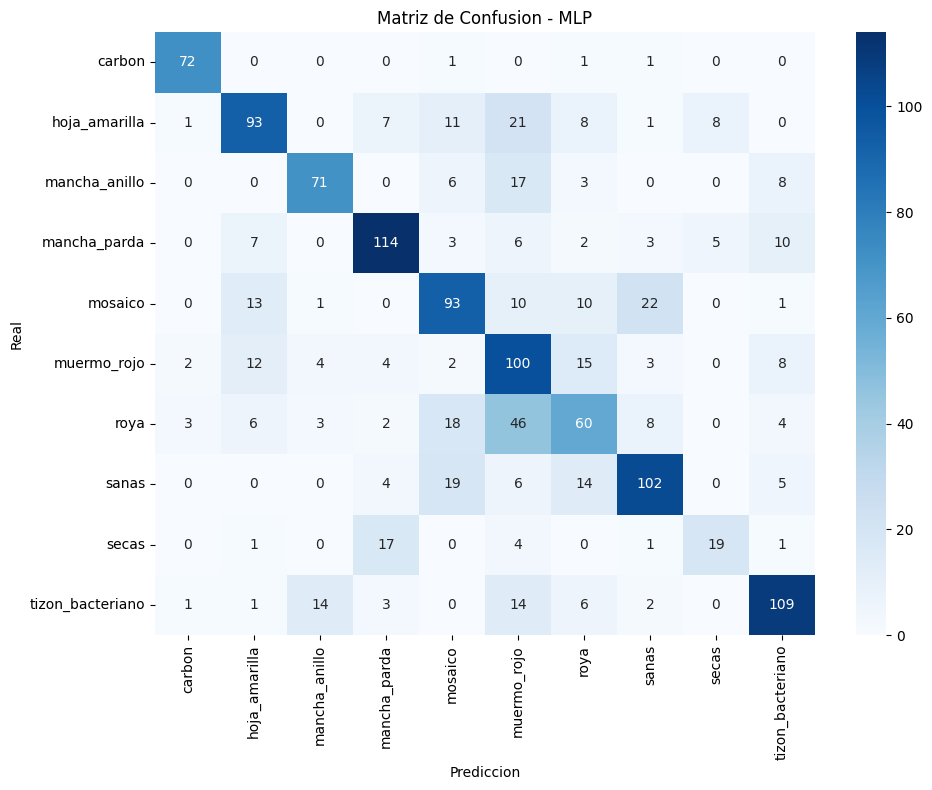

In [24]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, precision_score, recall_score

# Asegurar que el directorio exista
output_dir = '../outputs/graphics'
os.makedirs(output_dir, exist_ok=True)

# Si se guardó el mejor modelo, cargarlo para evaluación
model_file = 'mlp_best_model.keras'
if os.path.exists(model_file):
    mlp_model = tf.keras.models.load_model(model_file)
    print('Modelo MLP cargado desde', model_file)
else:
    print('No se encontró', model_file, '. Usando modelo en memoria (entrenado recientemente).')

# Predicciones y métricas en test
mlp_pred_probs = mlp_model.predict(test_ds_mlp, verbose=1)

# Reconstruir el vector y_test_mlp real a partir del dataset generador
y_test_mlp = np.concatenate([y for x, y in test_ds_mlp], axis=0)
y_test_mlp = np.argmax(y_test_mlp, axis=1)

mlp_pred_labels = np.argmax(mlp_pred_probs, axis=1)

# Métricas
mlp_accuracy = accuracy_score(y_test_mlp, mlp_pred_labels)
mlp_precision = precision_score(y_test_mlp, mlp_pred_labels, average='weighted', zero_division=0)
mlp_recall = recall_score(y_test_mlp, mlp_pred_labels, average='weighted', zero_division=0)
mlp_f1 = f1_score(y_test_mlp, mlp_pred_labels, average='weighted', zero_division=0)

print("\nRESULTADOS MLP:")
print(f'  Accuracy:  {mlp_accuracy:.4f}')
print(f'  Precision: {mlp_precision:.4f}')
print(f'  Recall:    {mlp_recall:.4f}')
print(f'  F1-Score:  {mlp_f1:.4f}')

# Matriz de confusión
mlp_cm = confusion_matrix(y_test_mlp, mlp_pred_labels)

print("\nReporte por clase (MLP):")
print(classification_report(y_test_mlp, mlp_pred_labels, target_names=class_names, zero_division=0))

# Gráfica de accuracy
plt.figure(figsize=(8,5))
plt.plot(mlp_history.history['accuracy'], label='accuracy')
plt.plot(mlp_history.history['val_accuracy'], label='val_accuracy')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(output_dir, '01_mlp_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

# Gráfica de loss
plt.figure(figsize=(8,5))
plt.plot(mlp_history.history['loss'], label='loss')
plt.plot(mlp_history.history['val_loss'], label='val_loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(output_dir, '01_mlp_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

# Matriz de confusión
plt.figure(figsize=(10,8))
ax = sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=class_names, yticklabels=class_names)

ax.set_title('Matriz de Confusion - MLP')
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')

plt.tight_layout()

# Guardar antes de mostrar
plt.savefig(os.path.join(output_dir, '01_mlp_matriz_confusion.png'),
            dpi=150, bbox_inches='tight')

plt.show()